In [40]:
#Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageEnhance

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
# Set the path to the raw digit dataset

dataset_path = "digits_dataset/Photos of digits"

print("Dataset path:", dataset_path)

Dataset path: digits_dataset/Photos of digits


In [5]:
# Check that the dataset folder exists

if os.path.exists(dataset_path):
    print("Dataset folder exists.")
else:
    print("Dataset folder does not exist.")

Dataset folder exists.


In [6]:
# Check that all 10 digit folders are present

digits = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]

for digit in digits:
    folder = os.path.join(dataset_path, digit)

    if os.path.exists(folder):
        print("Digit", digit, ": OK")
    else:
        print("Digit", digit, ": MISSING")

Digit 0 : OK
Digit 1 : OK
Digit 2 : OK
Digit 3 : OK
Digit 4 : OK
Digit 5 : OK
Digit 6 : OK
Digit 7 : OK
Digit 8 : OK
Digit 9 : OK


In [7]:
# Count how many images we have for each digit

image_counts = {}

for digit in digits:
    folder = os.path.join(dataset_path, digit)

    files = os.listdir(folder)

    count = 0

    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            count += 1

    image_counts[digit] = count

    print("Digit", digit, ":", count)

Digit 0 : 100
Digit 1 : 109
Digit 2 : 118
Digit 3 : 100
Digit 4 : 87
Digit 5 : 80
Digit 6 : 96
Digit 7 : 56
Digit 8 : 100
Digit 9 : 100


In [8]:
# Calculate the total number of images in the dataset

total_images = sum(image_counts.values())

print("Total images:", total_images)

Total images: 946


In [9]:
# Check whether the digit folders contain unexpected files

non_image_files = []

for digit in digits:
    folder = os.path.join(dataset_path, digit)

    for file in os.listdir(folder):
        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            non_image_files.append(
                os.path.join(digit, file)
            )

print("Non-image files:", len(non_image_files))

if len(non_image_files) > 0:
    print(non_image_files)

Non-image files: 0


In [10]:
# Check whether all images can be opened correctly

bad_images = []

for digit in digits:
    folder = os.path.join(dataset_path, digit)

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            path = os.path.join(folder, file)

            try:
                image = Image.open(path)
                image.load()

            except:
                bad_images.append(path)

print("Bad images:", len(bad_images))

Bad images: 0


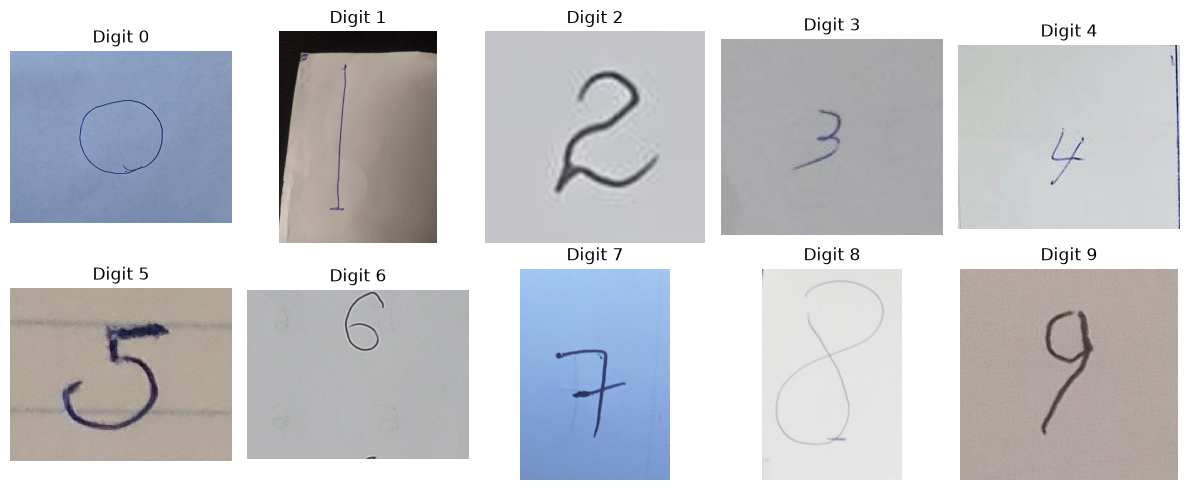

In [11]:
# Display one raw image from each digit for visual inspection

plt.figure(figsize=(12, 5))

for digit in digits:

    folder = os.path.join(dataset_path, digit)

    files = os.listdir(folder)

    image_file = files[0]

    image_path = os.path.join(folder, image_file)

    image = Image.open(image_path)

    plt.subplot(2, 5, int(digit) + 1)
    plt.imshow(image)
    plt.title("Digit " + digit)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Check the size of the raw images

widths = []
heights = []

for digit in digits:
    folder = os.path.join(dataset_path, digit)

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            path = os.path.join(folder, file)

            image = Image.open(path)

            width, height = image.size

            widths.append(width)
            heights.append(height)

print("Smallest width:", min(widths))
print("Largest width:", max(widths))
print("Smallest height:", min(heights))
print("Largest height:", max(heights))

Smallest width: 107
Largest width: 2566
Smallest height: 105
Largest height: 2925


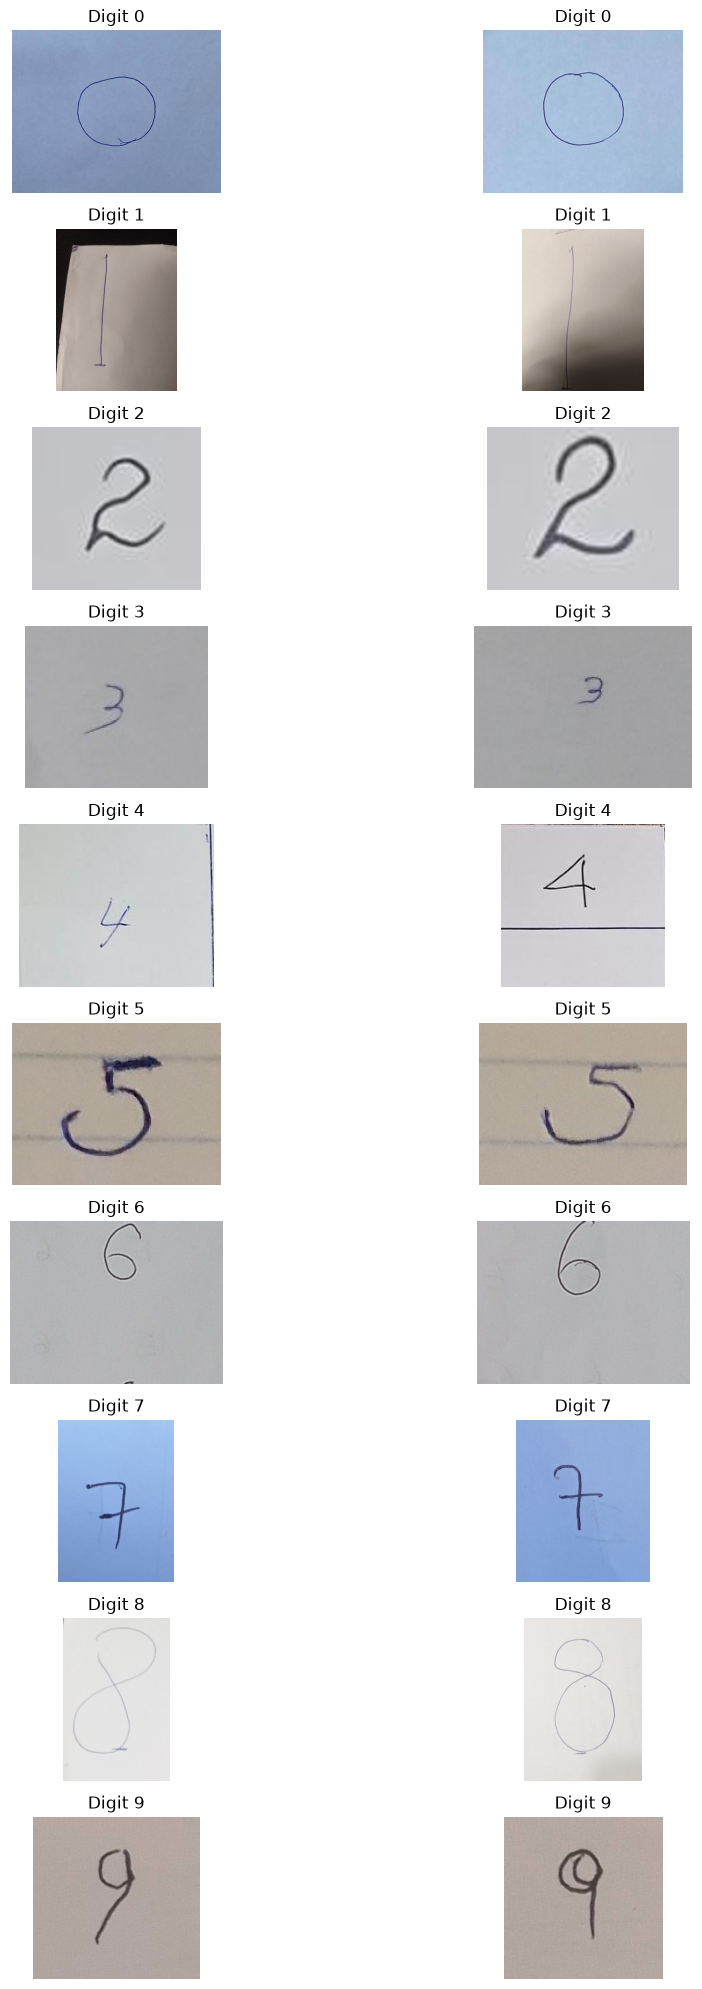

In [13]:
# Display several raw images from each digit

plt.figure(figsize=(12, 20))

for digit in digits:

    folder = os.path.join(dataset_path, digit)

    files = os.listdir(folder)

    for i in range(2):

        image_file = files[i]

        image_path = os.path.join(folder, image_file)

        image = Image.open(image_path)

        position = int(digit) * 2 + i + 1

        plt.subplot(10, 2, position)
        plt.imshow(image)
        plt.title("Digit " + digit)
        plt.axis("off")

plt.tight_layout()
plt.show()

Original size: (934, 726)


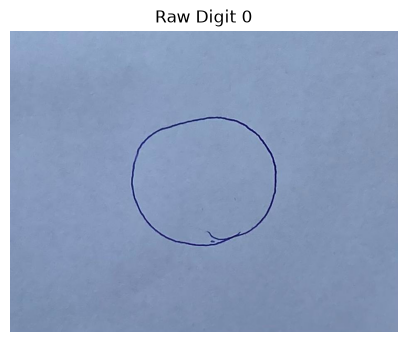

In [14]:
# Open one raw image so we can test the crop

test_folder = os.path.join(dataset_path, "0")
test_file = os.listdir(test_folder)[0]
test_path = os.path.join(test_folder, test_file)

test_image = Image.open(test_path)

print("Original size:", test_image.size)

plt.figure(figsize=(5, 5))
plt.imshow(test_image)
plt.title("Raw Digit 0")
plt.axis("off")
plt.show()

In [15]:
# Crop the image to remove unnecessary background

def crop_digit(image):
    gray = image.convert("L")

    # Convert the image to an array
    array = np.array(gray)

    # Find pixels that are darker than the background
    mask = array < 200

    # Find the position of the digit
    rows, cols = np.where(mask)

    # If no dark pixels are found, return the original image
    if len(rows) == 0:
        return image

    # Find the smallest box containing the digit
    left = cols.min()
    right = cols.max()
    top = rows.min()
    bottom = rows.max()

    # Crop the image
    cropped = image.crop((left, top, right + 1, bottom + 1))

    return cropped

Original size: (934, 726)
Cropped size: (934, 726)


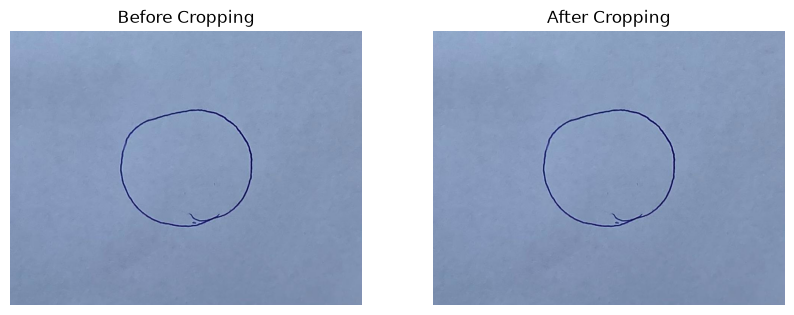

In [16]:
# Test the cropping method on our digit 0 image

cropped_image = crop_digit(test_image)

print("Original size:", test_image.size)
print("Cropped size:", cropped_image.size)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(test_image)
plt.title("Before Cropping")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_image)
plt.title("After Cropping")
plt.axis("off")

plt.show()

Grayscale image size: (934, 726)


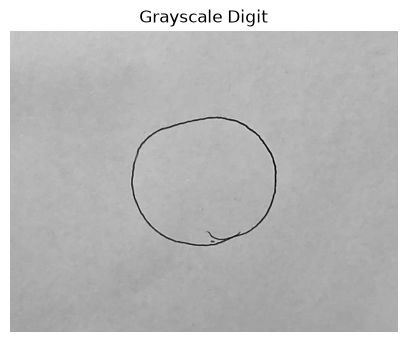

In [17]:
# Convert the cropped image from color to grayscale

gray_image = cropped_image.convert("L")

print("Grayscale image size:", gray_image.size)

plt.figure(figsize=(5, 5))
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Digit")
plt.axis("off")
plt.show()

In [18]:
# Check the pixel values of the grayscale image

gray_array = np.array(gray_image)

print("Minimum pixel value:", gray_array.min())
print("Maximum pixel value:", gray_array.max())

Minimum pixel value: 5
Maximum pixel value: 213


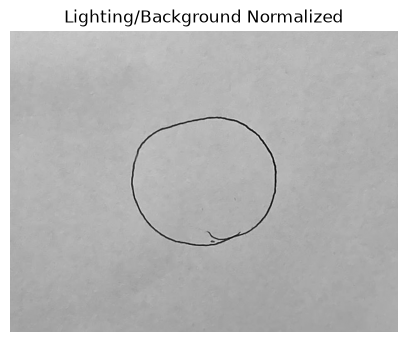

In [19]:
# Improve the contrast and background of the grayscale image

from PIL import ImageOps

normalized_light = ImageOps.autocontrast(gray_image)

plt.figure(figsize=(5, 5))
plt.imshow(normalized_light, cmap="gray")
plt.title("Lighting/Background Normalized")
plt.axis("off")
plt.show()

In [20]:
# Put the digit in the center of a square image

width, height = normalized_light.size

size = max(width, height)

centered_image = Image.new("L", (size, size), 255)

left = (size - width) // 2
top = (size - height) // 2

centered_image.paste(normalized_light, (left, top))

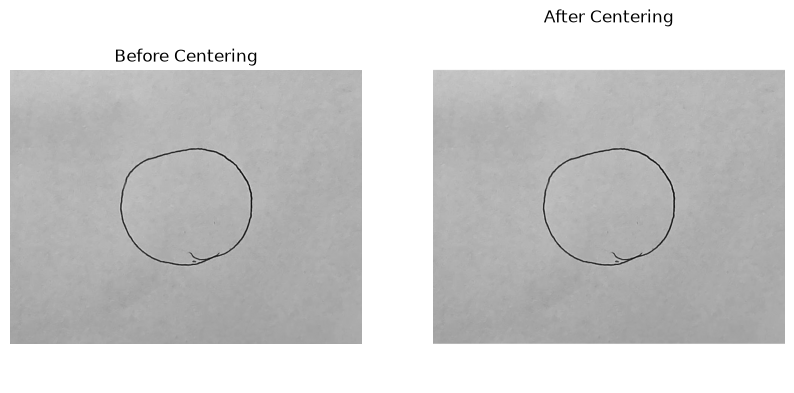

In [21]:
# Compare the digit before and after centering

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(normalized_light, cmap="gray")
plt.title("Before Centering")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(centered_image, cmap="gray")
plt.title("After Centering")
plt.axis("off")

plt.show()

In [22]:
# Check the size of the centered image

print("Centered image size:", centered_image.size)

Centered image size: (934, 934)


In [23]:
# Resize the centered image to 32 × 32 pixels

resized_image = centered_image.resize((32, 32))

print("New image size:", resized_image.size)

New image size: (32, 32)


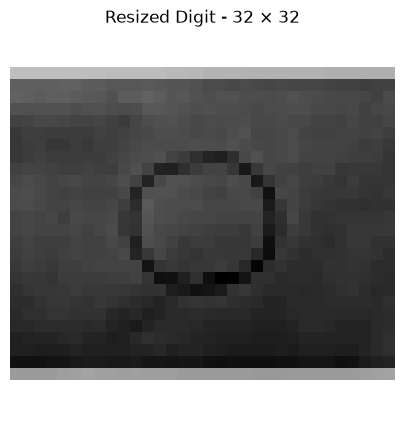

In [24]:
# Display the resized digit

plt.figure(figsize=(5, 5))

plt.imshow(resized_image, cmap="gray")

plt.title("Resized Digit - 32 × 32")
plt.axis("off")

plt.show()

In [25]:
# Check pixel values before normalization

image_array = np.array(resized_image)

print("Minimum value:", image_array.min())
print("Maximum value:", image_array.max())

Minimum value: 153
Maximum value: 255


In [26]:
# Convert pixel values from 0-255 to 0-1

normalized_image = image_array / 255.0

print("Minimum value:", normalized_image.min())
print("Maximum value:", normalized_image.max())

Minimum value: 0.6
Maximum value: 1.0


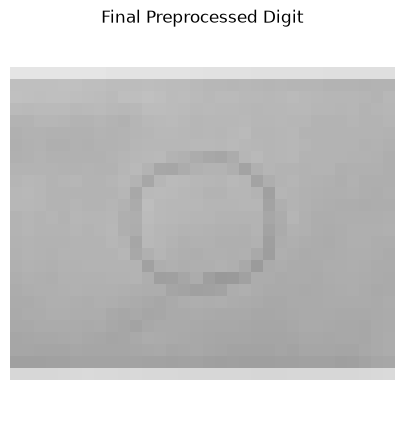

In [27]:
# Display the final preprocessed image

plt.figure(figsize=(5, 5))

plt.imshow(
    normalized_image,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title("Final Preprocessed Digit")
plt.axis("off")

plt.show()

In [28]:
# Create one function that performs all preprocessing steps

def preprocess_image(image):

    # Convert to grayscale
    image = image.convert("L")

    # Crop the digit
    array = np.array(image)
    mask = array < 200

    rows, cols = np.where(mask)

    if len(rows) > 0:
        left = cols.min()
        right = cols.max()
        top = rows.min()
        bottom = rows.max()

        image = image.crop(
            (left, top, right + 1, bottom + 1)
        )

    # Improve lighting and background
    image = ImageOps.autocontrast(image)

    # Make the image square and center the digit
    width, height = image.size
    size = max(width, height)

    centered = Image.new("L", (size, size), 255)

    left = (size - width) // 2
    top = (size - height) // 2

    centered.paste(image, (left, top))

    # Resize to 32 × 32
    image = centered.resize((32, 32))

    # Convert to numbers and normalize to 0-1
    image = np.array(image) / 255.0

    return image

In [29]:
# Test the complete preprocessing function on one image

processed_image = preprocess_image(test_image)

print("Image shape:", processed_image.shape)
print("Minimum value:", processed_image.min())
print("Maximum value:", processed_image.max())

Image shape: (32, 32)
Minimum value: 0.6
Maximum value: 1.0


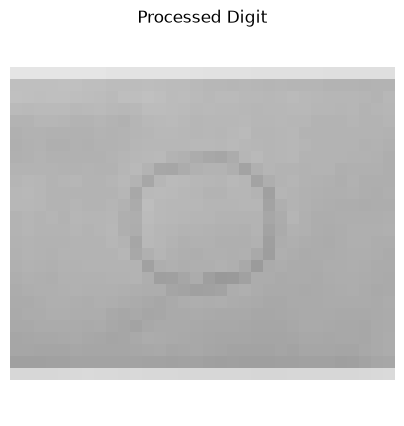

In [30]:
# Display the result of the complete preprocessing function

plt.figure(figsize=(5, 5))

plt.imshow(
    processed_image,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title("Processed Digit")
plt.axis("off")

plt.show()

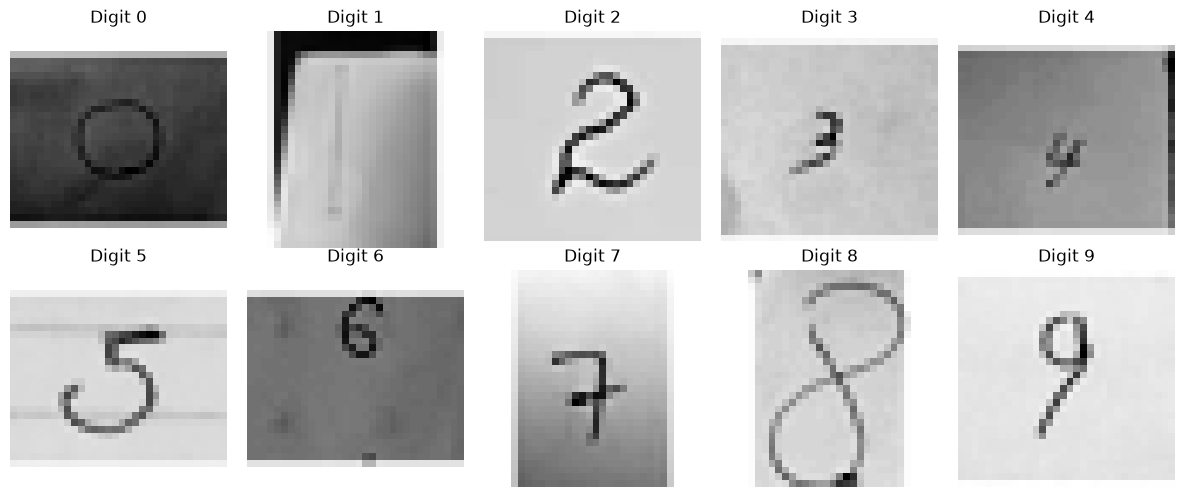

In [31]:
# Test the preprocessing function on one image from each digit

plt.figure(figsize=(12, 5))

for digit in digits:

    folder = os.path.join(dataset_path, digit)

    files = os.listdir(folder)

    image_path = os.path.join(folder, files[0])

    image = Image.open(image_path)

    processed = preprocess_image(image)

    plt.subplot(2, 5, int(digit) + 1)
    plt.imshow(processed, cmap="gray")
    plt.title("Digit " + digit)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
# Apply the preprocessing function to all images

X = []
y = []

for digit in digits:

    folder = os.path.join(dataset_path, digit)

    for file in os.listdir(folder):

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            path = os.path.join(folder, file)

            image = Image.open(path)

            processed = preprocess_image(image)

            X.append(processed)
            y.append(int(digit))

print("Images processed:", len(X))
print("Labels:", len(y))

Images processed: 946
Labels: 946


In [33]:
# Convert the image and label lists into NumPy arrays

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (946, 32, 32)
y shape: (946,)


In [34]:
# Check that all pixel values are normalized between 0 and 1

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


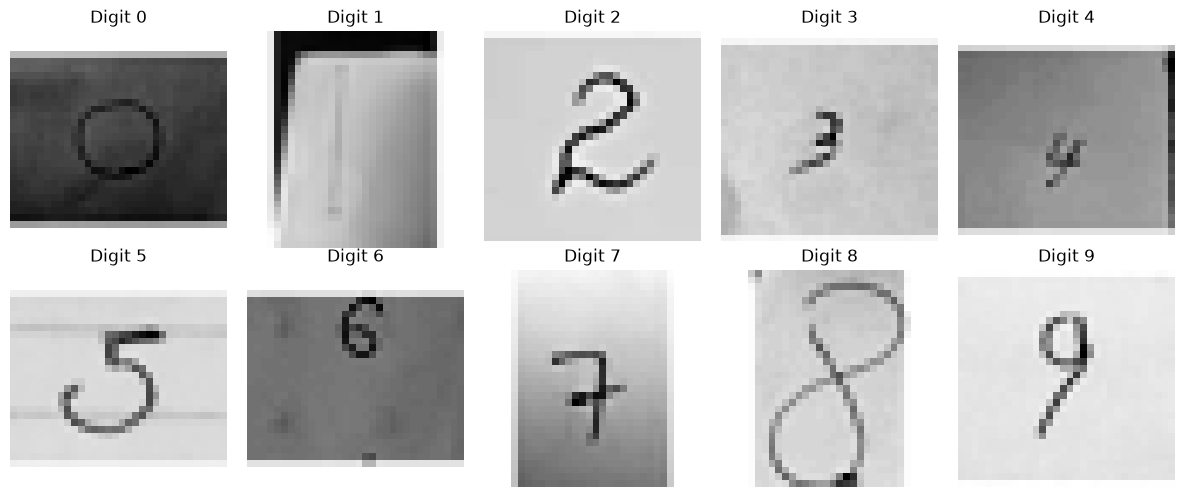

In [35]:
# Display one processed image from each digit

plt.figure(figsize=(12, 5))

for digit in range(10):

    index = np.where(y == digit)[0][0]

    plt.subplot(2, 5, digit + 1)
    plt.imshow(X[index], cmap="gray")
    plt.title("Digit " + str(digit))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
# Check that all pixel values are normalized between 0 and 1

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [37]:
# Check which digit labels are in our dataset

print("Labels:", np.unique(y))

Labels: [0 1 2 3 4 5 6 7 8 9]


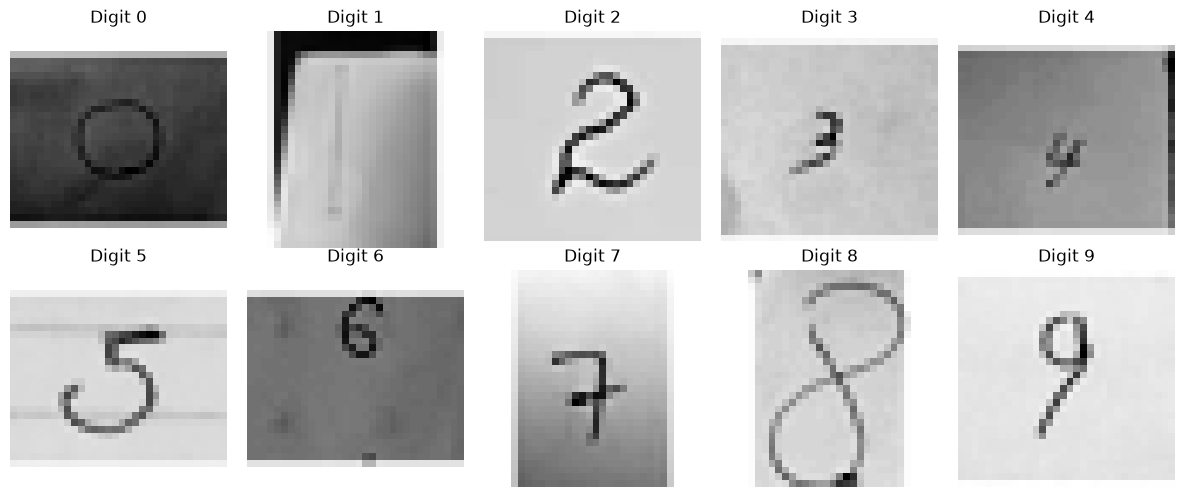

In [38]:
# Display one processed image from each digit

plt.figure(figsize=(12, 5))

for digit in range(10):

    index = np.where(y == digit)[0][0]

    plt.subplot(2, 5, digit + 1)
    plt.imshow(X[index], cmap="gray")
    plt.title("Digit " + str(digit))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [41]:
# Split the dataset into training data and temporary data

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Temporary images:", len(X_temp))

Training images: 662
Temporary images: 284


In [42]:
# Split the temporary data into validation and test data

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Test images:", len(X_test))

Training images: 662
Validation images: 142
Test images: 142


In [43]:
# Check the shape of each dataset

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (662, 32, 32) (662,)
Validation: (142, 32, 32) (142,)
Test: (142, 32, 32) (142,)


In [44]:
# Count each digit in the training, validation, and test sets

print("Training:", np.bincount(y_train))
print("Validation:", np.bincount(y_val))
print("Test:", np.bincount(y_test))

Training: [70 76 83 70 61 56 67 39 70 70]
Validation: [15 16 18 15 13 12 14  9 15 15]
Test: [15 17 17 15 13 12 15  8 15 15]


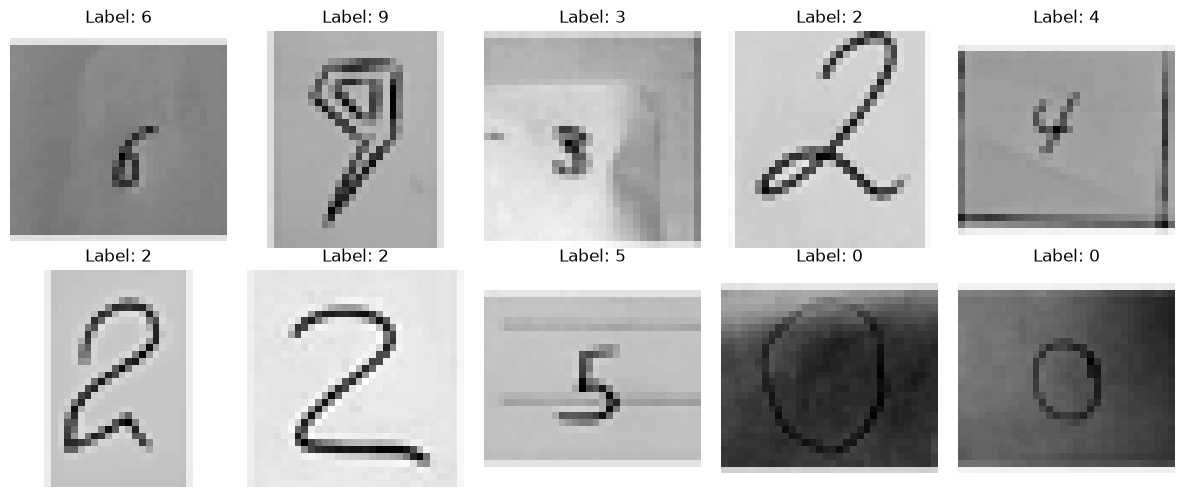

In [45]:
# Display some test images

plt.figure(figsize=(12, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title("Label: " + str(y_test[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
# Add one channel to the grayscale images

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Training shape: (662, 32, 32, 1)
Validation shape: (142, 32, 32, 1)
Test shape: (142, 32, 32, 1)


In [47]:
# Create augmentation for training images only

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10)
])

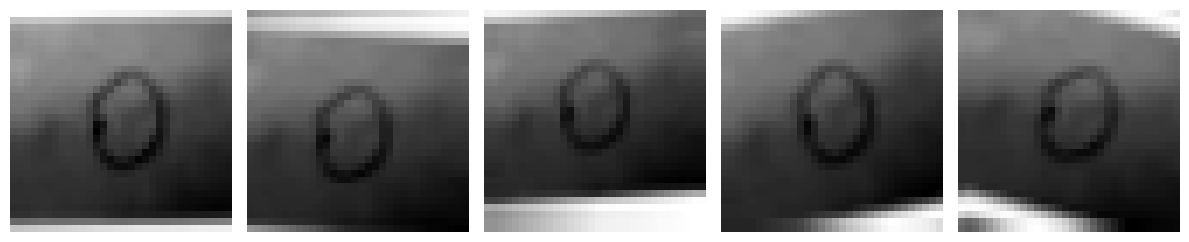

In [48]:
# Display different augmented versions of one training image

image = X_train[0]

plt.figure(figsize=(12, 5))

for i in range(5):

    augmented = data_augmentation(
        tf.expand_dims(image, 0),
        training=True
    )

    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented[0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
# Build a small CNN for handwritten digit recognition

model = models.Sequential([

    data_augmentation,

    layers.Conv2D(16, (3, 3), activation="relu", input_shape=(32, 32, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(32, activation="relu"),

    layers.Dense(10, activation="softmax")
])

C:\Users\HP\anaconda3\envs\cluster\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
# Display the CNN architecture

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (1, 32, 32, 1)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (1, 30, 30, 16)             │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (1, 15, 15, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (1, 13, 13, 32)             │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (1, 6, 6, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (1, 1152)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (1, 32)                     │          36,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (1, 10)                     │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,026 (164.16 KB)

 Trainable params: 42,026 (164.16 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Configure the model before training

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [52]:
# Train the CNN using the training data

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.1465 - loss: 2.2868 - val_accuracy: 0.2042 - val_loss: 2.2269
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2009 - loss: 2.2181 - val_accuracy: 0.2113 - val_loss: 2.1267
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2734 - loss: 2.1058 - val_accuracy: 0.2746 - val_loss: 1.9447
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3338 - loss: 1.9161 - val_accuracy: 0.4155 - val_loss: 1.8225
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3837 - loss: 1.7388 - val_accuracy: 0.3732 - val_loss: 1.5546
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3943 - loss: 1.6142 - val_accuracy: 0.4085 - val_loss: 1.6132
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4834 - loss: 1.4406 - val_accuracy: 0.4366 - val_loss: 1.5327
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4985 - loss: 1.3456 - val_accuracy: 0.5915 - 

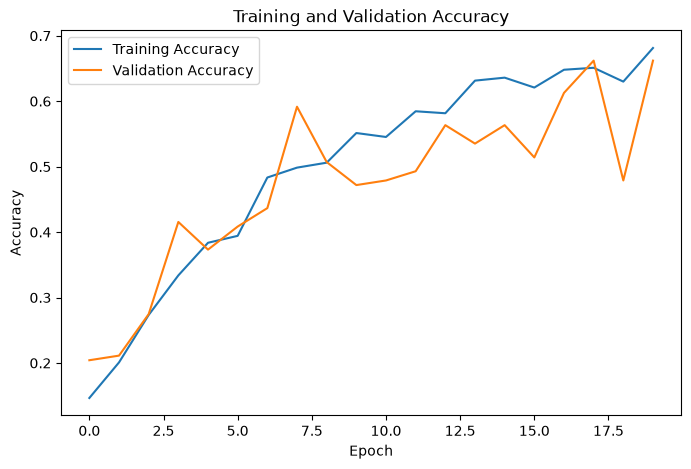

In [53]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

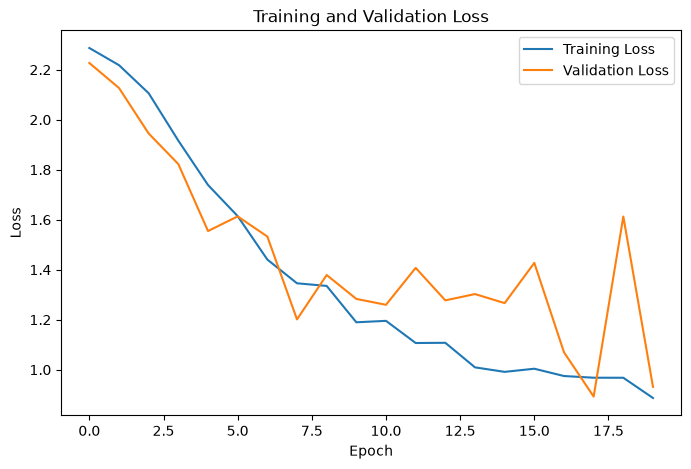

In [54]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [55]:
# Evaluate the trained CNN on the untouched test set

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7254 - loss: 0.9669
Test accuracy: 0.7253521084785461
Test loss: 0.966916024684906


In [56]:
# Make predictions for the test images

predictions = model.predict(X_test)

print("Prediction shape:", predictions.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediction shape: (142, 10)


In [57]:
# Choose the digit with the highest probability

y_pred = np.argmax(predictions, axis=1)

print("Predicted digits:", y_pred[:20])
print("Actual digits:   ", y_test[:20])

Predicted digits: [0 9 8 2 6 2 2 5 0 0 8 0 5 1 9 5 9 0 5 1]
Actual digits:    [6 9 3 2 4 2 2 5 0 0 8 4 5 1 9 3 9 0 5 1]


In [58]:
from sklearn.metrics import classification_report

# Show precision, recall, and F1-score for each digit

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.50      1.00      0.67        15
           1       0.94      1.00      0.97        17
           2       1.00      0.94      0.97        17
           3       0.50      0.13      0.21        15
           4       0.00      0.00      0.00        13
           5       0.71      1.00      0.83        12
           6       0.64      0.47      0.54        15
           7       0.60      0.75      0.67         8
           8       0.72      0.87      0.79        15
           9       0.88      1.00      0.94        15

    accuracy                           0.73       142
   macro avg       0.65      0.72      0.66       142
weighted avg       0.67      0.73      0.67       142



In [59]:
from sklearn.metrics import confusion_matrix

# Create a confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[15  0  0  0  0  0  0  0  0  0]
 [ 0 17  0  0  0  0  0  0  0  0]
 [ 0  0 16  0  0  0  0  0  0  1]
 [ 1  0  0  2  0  3  1  4  4  0]
 [ 8  0  0  1  0  1  3  0  0  0]
 [ 0  0  0  0  0 12  0  0  0  0]
 [ 6  0  0  1  0  0  7  0  1  0]
 [ 0  1  0  0  0  0  0  6  0  1]
 [ 0  0  0  0  1  1  0  0 13  0]
 [ 0  0  0  0  0  0  0  0  0 15]]


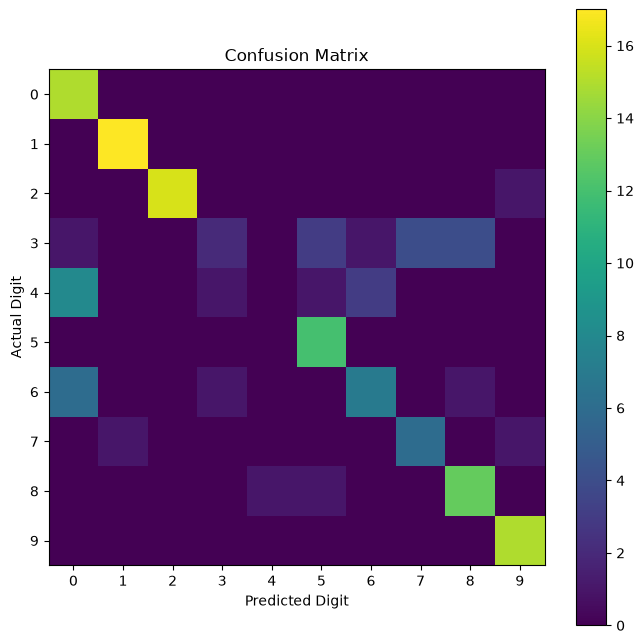

In [60]:
# Display the confusion matrix as a graph

plt.figure(figsize=(8, 8))

plt.imshow(cm)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.show()

In [61]:
# Find images that the model predicted incorrectly

wrong = np.where(y_pred != y_test)[0]

print("Number of wrong predictions:", len(wrong))

Number of wrong predictions: 39


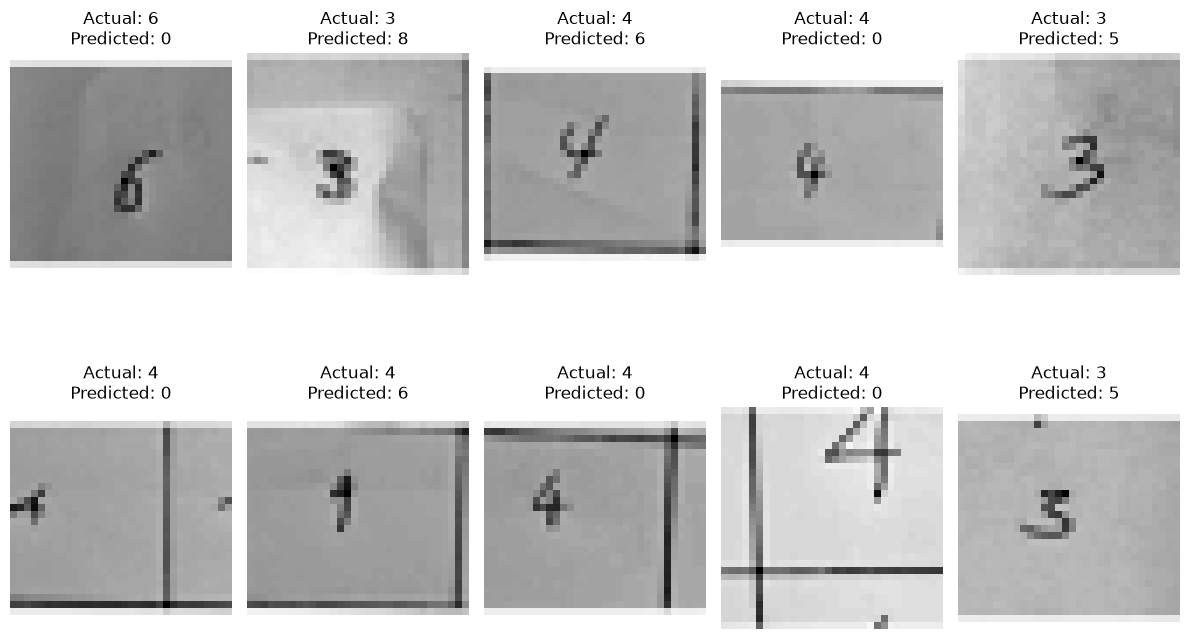

In [62]:
# Display some images that the model classified incorrectly

plt.figure(figsize=(12, 8))

number_to_show = min(10, len(wrong))

for i in range(number_to_show):

    index = wrong[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[index].squeeze(),
        cmap="gray"
    )

    plt.title(
        "Actual: " + str(y_test[index]) +
        "\nPredicted: " + str(y_pred[index])
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [63]:
# Save the trained CNN model

model.save("handwritten_digit_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [64]:
# Load the saved CNN model

loaded_model = tf.keras.models.load_model(
    "handwritten_digit_model.keras"
)

print("Model loaded successfully.")

Model loaded successfully.


In [65]:
# Create a function to recognize a new handwritten digit

def predict_digit(image_path):

    image = Image.open(image_path)

    image = preprocess_image(image)

    image = image.reshape(1, 32, 32, 1)

    prediction = loaded_model.predict(image, verbose=0)

    digit = np.argmax(prediction)

    confidence = np.max(prediction)

    return digit, confidence

In [66]:
# Test the prediction function with one image

test_folder = os.path.join(dataset_path, "5")

test_file = os.listdir(test_folder)[0]

test_path = os.path.join(
    test_folder,
    test_file
)

digit, confidence = predict_digit(test_path)

print("Predicted digit:", digit)
print("Confidence:", confidence)

Predicted digit: 9
Confidence: 0.8760358


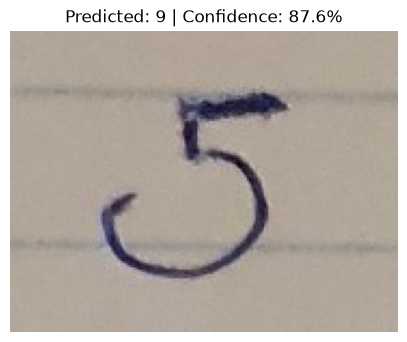

In [67]:
# Display the image and the model prediction

image = Image.open(test_path)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(
    "Predicted: " + str(digit) +
    " | Confidence: " + str(round(confidence * 100, 2)) + "%"
)
plt.axis("off")
plt.show()

In [68]:
# Test the model with another handwritten digit

test_folder = os.path.join(dataset_path, "8")

test_file = os.listdir(test_folder)[0]

test_path = os.path.join(
    test_folder,
    test_file
)

digit, confidence = predict_digit(test_path)

print("Predicted digit:", digit)
print("Confidence:", round(confidence * 100, 2), "%")

Predicted digit: 8
Confidence: 52.9 %
